## Introduction
<h5><center><i>BBVA - Universidad de Mondragón</i></center><h5>


<h4><center>
Luis Manuel García Muñoz</center><h4>
<h4><center>
Ignacio Ramos García</center><h4>




The main goal of this project is to implement a **Nerual Network** capable of decrease computational complexity in finantial products valuation which a close formula does not exist, learning in a generalized and automatically way non-lineal and temporal relations.

It exists a close formula in certain derivatives under some assumption. Nevertheless, market is complex, and with exotics derivatives for instance, Monte Carlo simulations must be carried out, which is inneficient and time consuming.

Furthermore, under some market regulations such as FRTB, porftolios are simulated in different scenarios (Stress scenarios), which price aproximattion are needed.


The product to be analyzed in this project is an **Asian Option** with geometric average consisting on **three underlyings**. For Asian options the payoff is determined by the average underlying price over some pre-set period of time. Especifically, in this project the average implemented is geometric.

The assets selected could be stocks from IBEX 35 from the same sector i.e Santander, BBVA and Caixabank.

## Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats.mstats import gmean
from numpy.linalg import cholesky

## Simulations


The training set is generated or simulated with **Monte-Carlo** under geometric Brownian motion with a given volatility $\sigma$, a risk free rate of $\mu$, and no dividends. The data (X) will be the spots prices simulated (S) all over time steps.

Path simulation with **Black-Scholes** formula:
$$
\begin{array}{l}
X_{t_j} := S_{t_j} = S_{t_{j-1}} * e^{(\mu - \frac{\sigma^2}{ 2}) * \Delta t + \sigma * \Delta W_t }
\end{array}
$$

being $S_0$ initial spot prices of the assets and $\Delta t = t_j-t_{j-1}$.

Under a derivatives valuation framework we must simulate all risk factors (underlyings) with the same expected return, that is the free risk rate. Therefore, all $\mu$ are the same for the three assets, and equal to the unique discount rate which we assume to be:

$$
\begin{array}{l}
\mu = 0.01
\end{array}
$$

Furthermore, the Time To Maturity of the option is five years (TTM =5). The number of equally spaced time steps $\{t_j\}$ is 20 appart from $t_0=0$. In this example, we are going to simulate 1000 different paths of prices for each underlying or risk factor. Nevertheless the number of simulations used to train the NN model could be modified since the model performance will depend on this.



In [ ]:
TTM = 5
num_steps = 20
delta_t = TTM / num_steps
num_sims = 1000
num_assets = 3

mu = np.array([0.01, 0.01, 0.01])
sigma = np.array([0.2, 0.2, 0.3])

S_0 = np.array([1,1,1])

The three assets must be correlated, as we have selected stocks from the same sector. We create a 3x3 diagonal matrix rho [$\rho$] of correlations.

In [ ]:
rho = np.array([[1,0.8,0.2], [0.8,1,0.6],[0.2,0.6,1]])
print(rho)

[[1.  0.8 0.2]
 [0.8 1.  0.6]
 [0.2 0.6 1. ]]


In order to simulate correlated assets with Monte Carlo technique, we implemnt Cholesky decomposition:


$$
\begin{array}{l}
[\rho] = A^T.A
\end{array}
$$

being A a triangular inferior matrix.

Then we multiply this matrix A with the Brownian movement $\bigtriangleup W_t$ to obtain the covariance matrix needed to simulate paths.

In [ ]:
m = cholesky(rho)
print(m)

[[1.         0.         0.        ]
 [0.8        0.6        0.        ]
 [0.2        0.73333333 0.64978629]]


Monte Carlo Simulations:


In [ ]:
inc_W = np.random.normal(size=(num_sims, num_steps, num_assets), scale = np.sqrt(delta_t))

# Paths correlated
inc_W_correl = np.matmul(inc_W, m.T)

gross_rets = S_0 * np.exp((mu - 0.5 *sigma **2) * delta_t + sigma * inc_W_correl)

# S_T = np.cumprod(np.concatenate((S_0.reshape(-1,1), gross_rets), axis = 1), axis = 1)

assets = np.cumprod(gross_rets, axis = 1)


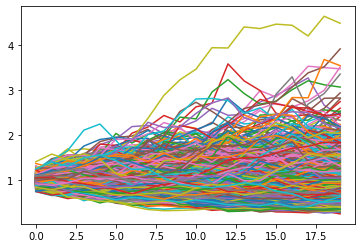

In [ ]:
plt.plot(assets[:,:,0].T);

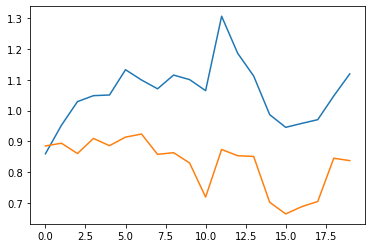

In [ ]:
plt.plot(assets[0,:,0])
plt.plot(assets[0,:,1])


## Geometric Asian Option Payoff

$$
\begin{array}{l}
V_T = (\prod_{j=1}^{n_{steps}}\prod_{k=1}^{K} \frac{S_j ^k}{S_0 ^k})^ \frac{1}{n_{steps}*K} =  (\prod_{j=1}^{n_{steps}}\prod_{k=1}^{K} r_j ^k)^ \frac{1}{n_{steps}*K}
\end{array}
$$

being K the number of assets

In [ ]:
returns = assets.copy()
for k in range(0,3):
  returns[:,:,k] = (assets[:,:,k]/S_0[k])

In [ ]:
#Gmeans axis=1 implements geometric average in each columns, that is for every asset
#Gmeans axis=0 computes geometric average in row columns,that is for every step

V_T = np.zeros(num_sims)
for i in range(0,num_sims):
   V_T[i] = gmean(gmean(returns[i,:,:],axis=1),axis=0)


## Time Value of Money

The payoff is simulated in T, Time To Maturity, that is five years. Let's compute the **Present Value** of the payoff, and thus, the value of the payoff in every time step:

$$
\begin{array}{l}
Y = V_{h,t_n} = V_T ^ h \exp{(-\mu* (n_{steps}-t_n) \Delta t)}
\end{array}
$$

being h the number of the simulation, and $t_n$ the number of the time step.

That is the final output (Y) it's a matrix of size ($n_{sims}$ x $n_{steps}$)





In [ ]:
Y = np.zeros((num_sims,num_steps))

for h in range(0,num_sims):
  for n in range(0,num_steps):

    Y[h,n] = max(V_T[h]-1,0)*np.exp(- mu[0]* (num_steps - n )*delta_t)


## Train-Test Splitting

X are simulated spot prices all over the time steps.

Y payoffs all over the time steps of the Asian Option with geometric average

*   X =  matrix ($n_{simulations}$ x $n_{steps}$ x $K_{assets}$)
*   Y = matrix ($n_{simulations}$ x $n_{steps}$ )

Let's split train and test with 80% and 20% of data each.







In [ ]:
n_train = int(num_sims *0.8)

X_train = assets[:n_train,:,:]
Y_train = Y[:n_train,:]

X_test = assets[n_train:,:,:]
Y_test = Y[n_train:,:]


In [ ]:
print(f'X train set size: {X_train.shape}')
print(f'X teste set size: {X_test.shape}')
print(f'Y train set size: {Y_train.shape}')
print(f'Y teste set size: {Y_test.shape}')

X train set size: (800, 20, 3)
X teste set size: (200, 20, 3)
Y train set size: (800, 20)
Y teste set size: (200, 20)


## Pruebas


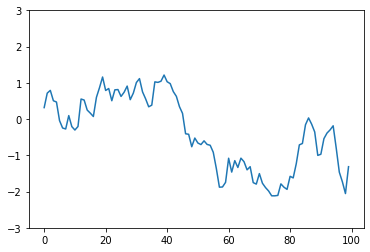

In [ ]:
T = 5
num_steps = 100
delta_t = T / num_steps
alpha = 0.9

W_inc = np.random.normal(size=num_steps, scale = np.sqrt(delta_t**alpha))

W = np.cumsum(W_inc)

plt.plot(W)

test = plt.gca().set_ylim(-3,3);


$\int_{s=0}^TdW_sds$

$\int_{s=0}^TdW_s^2$

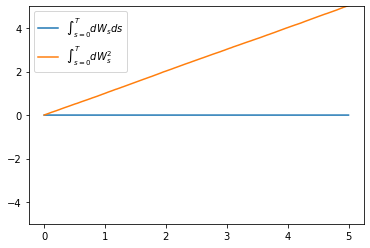

In [ ]:
TTM = 5
num_steps = 100000
delta_t = TTM / num_steps
alpha = 1

dW = np.random.normal(size=num_steps, scale = np.sqrt(delta_t**alpha))

int_dW_dt = np.cumsum(dW * delta_t)
int_dW_squared = np.cumsum((dW ** 2) )

plt.plot(np.linspace(0,TTM, num_steps), int_dW_dt, label = r'$\int_{s=0}^TdW_sds$')
plt.plot(np.linspace(0,TTM, num_steps), int_dW_squared, label = r'$\int_{s=0}^TdW_s^2$')

plt.legend()
plt.gca().set_ylim(-5,5);



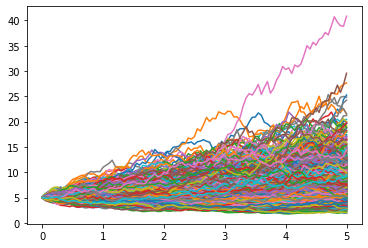

In [ ]:
TTM = 5
num_steps = 100
delta_t = TTM / num_steps
num_sims = 1000

S_0 = 5

mu = 0.10
sigma = 0.2

inc_W = np.random.normal(size=(num_sims, num_steps), scale = np.sqrt(delta_t))

gross_rets = np.exp((mu - 0.5 *sigma **2) * delta_t + sigma * inc_W)

S_T = np.cumprod(np.concatenate((S_0*np.ones((num_sims, 1)), gross_rets), axis = 1), axis = 1)


plt.plot(np.linspace(0,TTM, num_steps+1), S_T.T);

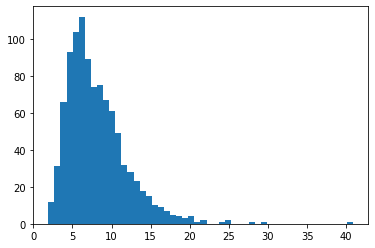

In [ ]:
plt.hist(S_T[:,-1], bins = 50);

In [ ]:
rho = np.array([[1,0.8,0.2], [0.8,1,0.6],[0.2,0.6,1]])
rho

array([[1. , 0.8, 0.2],
       [0.8, 1. , 0.6],
       [0.2, 0.6, 1. ]])

In [ ]:
norm_correl =np.matmul(np.random.normal(size = (100000,3)), m.T)

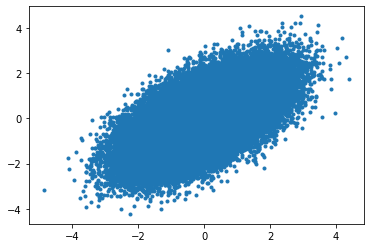

In [ ]:
plt.plot(norm_correl[:,1], norm_correl[:,2], '.')

In [ ]:
np.cov(norm_correl.T)

array([[0.99981456, 0.80060959, 0.20273043],
       [0.80060959, 1.00388539, 0.60560106],
       [0.20273043, 0.60560106, 1.0050074 ]])


Close formula:


$$
\begin{array}{l}
\hat{\sigma} = \frac{ \sigma ^2*T * (n_{steps} +1) (2*n_{steps} +1)}{6n_{steps}^2}\\
\hat{\mu} = \frac{1}{2}*\hat{\sigma} + \frac{({\mu -\frac{1}{2}*\sigma^2)}*(n_{steps}+1)*T}{2*n_{steps}}\\
d_1 = \frac{log(S) + \hat{\mu} +\frac{1}{2}*\hat{\sigma}}{\sqrt {\hat{\sigma}}}\\
d_2 = d1 - \sqrt{\hat{\sigma}}
\end{array}
$$


In [ ]:
def Geometric_Asian_Option(S, sigma, r, T, n, option_type):
    sigma_hat = sigma * math.sqrt((n + 1) * (2 * n + 1)/ (6 * n** 2))
    mu_hat = (r - 0.5 * sigma** 2)*(n + 1)/(2*n) + 0.5 * sigma_hat** 2
    d1_hat = (math.log(S ) + (mu_hat + 0.5 * sigma_hat** 2) * T)/(sigma_hat * math.sqrt(T))
    d2_hat = d1_hat - sigma_hat * math.sqrt(T)
    if option_type == 'Call':
        return math.exp(-r * T) * (S * math.exp(mu_hat * T) * norm.cdf(d1_hat) - K * norm.cdf(d2_hat))
    elif option_type == 'Put':
        return math.exp(-r * T) * (K * norm.cdf(-d2_hat) - S * math.exp(mu_hat * T) * norm.cdf(-d1_hat))

# Closed form formula

$$V_T = \left(\left(\prod_{i=1}^{n}\prod_{j=1}^{m}\frac{S_{t_i}^j}{S_{t_0}^j}\right)^{\frac{1}{nm}}-1\right)^+$$

$m$: number of underlying assets,

$n$: number of time steps.

Let's assume that:

$$S_T^j=S_t^j\exp\left(\left(r-\sigma_j^2/2\right)\left(t_n-t\right)+\sigma_i\left(W^j_T-W^j_t\right)\right)$$

And that the different underlyings are correlated with correlations $\rho_{ij}$.

We are interested in the following expected value

$$V_{t_v}=E\left[\left(\left(\prod_{i=1}^{n}\prod_{j=1}^{m}\frac{S_{t_i}^j}{S_{t_0}^j}\right)^{\frac{1}{nm}}-1\right)^+\exp\left(-r\left(t_n-t_v\right)\right)\Bigg{|}\mathcal{F}_{t_v}\right]$$

Where $\mathcal{F}_t$ represents that $S^j_{t_i}$ has been observed $\forall j$ and $t_i,\ \ i=0,\ldots,v$


$$V_{t_v}=E\left[\left(\left(\prod_{i=1}^{v}\prod_{j=1}^{m}\frac{S_{t_i}^j}{S_{t_0}^j}\right)^{\frac{1}{nm}}\left(\prod_{i=v+1}^{n}\prod_{j=1}^{m}\frac{S_{t_i}^j}{S_{t_0}^j}\right)^{\frac{1}{nm}}-1\right)^+\exp\left(-r\left(t_n-t_v\right)\right)\Bigg{|}\mathcal{F}_{t_v}\right]$$

Conditioned on $\mathcal{F}_t$, the term $\prod_{i=v+1}^{n}\prod_{j=1}^{m}\frac{S_{t_i}^j}{S_{t_0}^j}$ is the only stochastic term inside the expected value. Since under Black Scholes dynamics this term is the product of variables lognormally distributed, it is itself lognormal. Therefore, in order to derive the expression of the expected value we should derive the expression of the expected value and the variance of the logarithm of this term.



$$\left(\prod_{i=v+1}^{n}\prod_{j=1}^{m}\frac{S_{t_i}^j}{S_{t_0}^j}\right)^{\frac{1}{nm}}=\left(\prod_{i=v+1}^{n}\prod_{j=1}^{m}\frac{S_{t_v}^j}{S_{t_0}^j}\exp\left(r^j_{t_{v},t_{i}}\right)\right)^{\frac{1}{nm}}=\left(\prod_{j=1}^m\left(\frac{S_{t_v}^j}{S_{t_0}^j}\right)^{n-v}\right)^{\frac{1}{nm}}\exp\left(\frac{1}{nm}\sum_{i=v+1}^n\sum_{j=1}^mr^j_{t_{v},t_{i}}\right)$$

Where

$$r^j_{t_{v},t_{i}}=\left(r-\frac{\sigma_j^2}{2}\right)\left(t_i-t_v\right)+\sigma_j\left(W_{t_i}^j-W_{t_v}^j\right)$$

To obtain the mentioned expected value and variance we first obtain:

$$\bar{r}_i^j(t_v):=E\left[r^j_{t_{v},t_{i}}\Bigg{|}\mathcal{F}_{t_v}\right]=\left(r-\frac{\sigma_j^2}{2}\right)\left(t_i-t_v\right)$$

$$C_{i,j}^{h,k}(t_v):=C\left[r^h_{t_{v},t_{i}}, r^k_{t_{v},t_{j}}\Bigg{|}\mathcal{F}_{t_v}\right]=\sigma_h\sigma_k\rho_{h,k}\left(\min(t_i,t_j)-t_v\right)$$

$C$ represents the covariance.

So that:

$$\mu:=E\left[\frac{1}{nm}\sum_{i=v+1}^n\sum_{j=1}^mr^j_{t_{v},t_{i}}\Bigg{|}\mathcal{F}_{t_v}\right]=\frac{1}{nm}\sum_{i=v+1}^n\sum_{j=1}^m\bar{r}_i^j(t_v)=\frac{1}{nm}\sum_{j=1}^m\left(r-\frac{\sigma_j^2}{2}\right)\sum_{j=1}^m\left(t_j-t_v\right)$$

$$V:=\frac{1}{n^2m^2}\sum_{h=1}^m\sum_{k=1}^m\sum_{i=1}^n\sum_{j=1}^n C_{i,j}^{h,k}(t_v)=\frac{1}{n^2m^2}\left(\sum_{h=1}^m\sum_{k=1}^m\rho_{i,j}\sigma_i\sigma_j\right)\left(\sum_{i=v+1}^n\sum_{j=v+1}^n\left(\min(t_i,t_j)-t_v\right)\right)$$

And the stochastic term is distributed as

$$\exp\left(\frac{1}{nm}\sum_{i=v+1}^n\sum_{j=1}^mr^j_{t_{v},t_{i}}\right)\,{\buildrel d \over =}\,\exp\left(\mu +\sqrt{V}\phi\right),\ \phi \sim N(0,1)$$

So that the expected value we want to calculate is:

$$V_{t_v}=E\left[\left(\left(\prod_{i=1}^{v}\prod_{j=1}^{m}\frac{S_{t_i}^j}{S_{t_0}^j}\right)^{\frac{1}{nm}}\left(\prod_{j=1}^m\left(\frac{S_{t_v}^j}{S_{t_0}^j}\right)^{n-v}\right)^{\frac{1}{nm}}\exp\left(\mu +\sqrt{V}\phi\right)-1\right)^+\exp\left(-r\left(t_n-t_v\right)\right)\Bigg{|}\mathcal{F}_t\right]$$

This expected value is given by the Black formula with the following inputs:

* Risk fee rate: r
* Forward: $\left(\prod_{i=1}^{v}\prod_{j=1}^{m}\frac{S_{t_i}^j}{S_{t_0}^j}\right)^{\frac{1}{nm}}\left(\prod_{j=1}^m\left(\frac{S_{t_v}^j}{S_{t_0}^j}\right)^{n-v}\right)^{\frac{1}{nm}}\exp\left(\mu +\frac{V}{2}\right)$
* Strike = $1$
* Time to maturity: $t_n-t_v$
* Volatility: $\sqrt{\frac{V}{t_n-t_v}}$



In [ ]:
from scipy.stats import norm

N = norm.cdf

def Black(Forward, Strike, TTM, rate, Vol, IsCall):

  '''
  Inputs:
  -------
    Forward (float): Forward value
    Strike (float): strike price
    TTM (float): time to maturity in years
    rate (float): risk free rate
    Vol (float): volatility
    IsCall (bool): True if call option, False if put option
  Outputs:
  --------
    Option premium (float)
  '''

  if TTM >0:

    d1 = (np.log(Forward/Strike) + (Vol*Vol/2)*TTM)/(Vol*np.sqrt(TTM))
    d2 = (np.log(Forward/Strike) + (- Vol*Vol/2)*TTM)/(Vol*np.sqrt(TTM))

    if IsCall:

      return (Forward*N(d1)-Strike*N(d2))*np.exp(-rate*TTM)

    else:

      return (-Forward*N(-d1)+Strike*N(-d2))*np.exp(-rate*TTM)

  else:

    if IsCall:

      return np.maximum(Forward-Strike,0)

    else:

      return np.maximum(-Forward+Strike,0)


In [ ]:
def BasketGeomAsian(num_asian_dates, value_date_index, risk_free_rate, num_assets, assets_vol, assets_correl, initial_maturity, price_history, IsCall):
  '''
  Inputs:
  -------
  * num_asian_dates (int): number of asian dates. Notice that this includes the initial date, which fixes the initial spot values.
  * value_date_index (int): index, within the array of asian dates indicating the value date.
  * risk_free_rate (float): risk free rate
  * num_assets (int): number of underlying assets.
  * assets_vol (array(float)): array of indiv assets vols.
  * assets_correl (array(float, float)): matrix of correlations
  * initial_maturity (float): maturity of the product as seen on initial spot fixing date.
  * price_history (array(float, float)): history of fixings of the underlyings up to value date. Assets per row, time steps per column.
  * IsCall (bool): True if call option, False if put option
  Outputs:
  --------
  * Option price (float)
  '''

  init_time_array = np.linspace(0, initial_maturity, num_asian_dates)

  pending_times_array = init_time_array[value_date_index+1:] - init_time_array[value_date_index]

  mu = np.sum(risk_free_rate - 0.5*assets_vol*assets_vol)*np.sum(pending_times_array) / (num_assets * (num_asian_dates-1))

  diag_vol = np.diag(assets_vol.reshape(-1))

  cov_matrix = np.matmul(diag_vol, np.matmul(assets_correl, diag_vol))

  xx, yy = np.meshgrid(pending_times_array, pending_times_array, sparse=True)
  z = np.minimum(xx, yy)

  V = np.sum(cov_matrix) * np.sum(z) / (num_assets*num_assets*(num_asian_dates-1)*(num_asian_dates-1))

  Forward = np.power(np.prod(price_history[:, 1:value_date_index+1] / price_history[:,0].reshape(-1,1)),1.0/(num_assets * (num_asian_dates-1)))

  Forward *= np.power(np.prod(price_history[:,value_date_index] / price_history[:,0]), (num_asian_dates-value_date_index-1)/(num_assets * (num_asian_dates-1)))

  Forward *= np.exp(mu + 0.5 * V)

  remaining_maturity = initial_maturity - init_time_array[value_date_index]


  return Black(Forward, 1.0, remaining_maturity, risk_free_rate,np.sqrt(V / remaining_maturity), IsCall)




## Test closed form formula with Montecarlo

We simulate the underlyings up to a given value date:

In [ ]:
# Inputs:
#np.random.seed(1234)
rho = 0.1
risk_free_rate = 0.01
num_assets = 3
S_0 = np.array([1.0,2.0,3.0]).reshape(-1,1)
vols = np.array([0.2,0.3,0.05]).reshape(-1,1)
correl_matrix = rho = np.array([[1,rho,rho], [rho,1,rho],[rho,rho,1]])
IsCall = True
initial_maturity = 5
num_asian_dates = 11
value_date_index = 5

# Simulation of assets up to value date:

init_time_array = np.linspace(0, initial_maturity, num_asian_dates)

delta_t = initial_maturity / (num_asian_dates - 1)
num_steps = value_date_index

# Independent brownians
inc_W = np.random.normal(size=(num_assets, num_steps), scale = np.sqrt(delta_t))

# Cholesky matrix
m = cholesky(correl_matrix)

# Correlated brownians
inc_W_correl = np.matmul(m, inc_W)

# Gross returns
gross_rets = np.exp((risk_free_rate - 0.5 *vols **2) * delta_t + vols * inc_W_correl)

assets = np.cumprod(np.concatenate((S_0, gross_rets), axis = 1), axis = 1)

# We compute the analytic value
analytic = BasketGeomAsian(num_asian_dates, value_date_index, risk_free_rate, num_assets, vols, correl_matrix, initial_maturity, assets, IsCall)

print(analytic)

0.00015507822207932748


From that value date, we obtain the option premium by MC

Analytic:  0.00015507822207932748
Montecarlo:  0.00014878154765253206 0.0001398137419057525 0.00015774935339931163


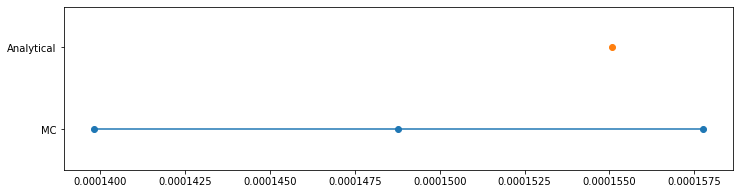

In [ ]:
from scipy.stats import norm

num_sims = 300000
conf_level = 0.95

num_remaining_steps = num_asian_dates - value_date_index -1

# Independent brownian motion (the axis order is done to be able to correlate them with a matrix multiplication)

inc_W_remaining = np.random.normal(size=(num_sims, num_remaining_steps, num_assets), scale = np.sqrt(delta_t))

# We correlate them

inc_W_correl_remaining = np.matmul(inc_W_remaining, m.T)

# We transpose the 3D matrix of correlated B. motion (path, asset, time step)

inc_W_correl_remaining = inc_W_correl_remaining.transpose([0,2,1])

aux = np.repeat(inc_W_correl[None,...],num_sims,axis=0)

# We attach the brownians obtained from t= 0 to value date

inc_W_correl_total = np.concatenate((aux, inc_W_correl_remaining), axis = 2)

# We compute exponential returns

gross_rets_total = np.exp((risk_free_rate - 0.5 *vols **2) * delta_t + vols * inc_W_correl_total)

# We simulate the underlyings

S_T = np.cumprod(np.concatenate((np.repeat(S_0.reshape(-1,1)[None,...],num_sims,axis=0), gross_rets_total), axis = 2), axis = 2)

# We compute the returns

rets = S_T[:,:,1:] / np.repeat(S_0.reshape(-1,1)[None,...],num_sims,axis=0)

# We obtain the payoff for every path

payoff = np.maximum(np.prod(rets, axis = (1,2))**(1/(num_assets * (num_asian_dates-1)))-1,0)

# Calculate the premium as the discounted average value

premium = np.mean(payoff*np.exp(-risk_free_rate*(initial_maturity-init_time_array[value_date_index])))

# Compute the MC confidence interval

std = np.std(payoff*np.exp(-risk_free_rate*(initial_maturity-init_time_array[value_date_index])))/np.sqrt(num_sims)

range = norm.ppf(1-(1-conf_level)/2) * std

print('Analytic: ', analytic)
print('Montecarlo: ', premium,premium-range, premium + range )

plt.plot([premium-range, premium, premium + range], [0,0,0], 'o-')
plt.plot([analytic], [0.1], 'o')

plt.gca().set_yticks([0,0.1])
plt.gca().set_yticklabels(['MC', 'Analytical'])
plt.gcf().set_size_inches(12,3)
plt.gca().set_ylim([-0.05,0.15]);



In [ ]:
S_T.shape

(300000, 3, 11)

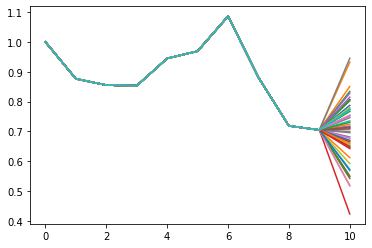

In [ ]:
plt.plot(S_T[0:50,0,:].T);